# Super-Block GEV Sensitivity Analysis for Max-DD Rankings

Validates whether single-sentence GEV shape parameter (xi) rankings across qualifying treebank-bin combinations agree with super-block (K) GEV estimates where EVT convergence is better justified.

**Method**: Loads UD dependency data, constructs super-blocks by partitioning K same-length sentences and taking block maxima, fits GEV via L-moments (primary) and MLE (secondary) with sign convention xi=-c, then compares xi rankings via Spearman rho with bootstrap CIs.

**Key finding**: GEV xi rankings show significant *negative* correlation between single-sentence and super-block approaches, failing the rho>0.8 criterion — but non-parametric quantile comparison reveals near-perfect rank preservation.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# lmoments3 — NOT pre-installed on Colab, always install
_pip('lmoments3')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'seaborn==0.13.2')
    _pip('scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import warnings
from collections import defaultdict
from typing import Any

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import genextreme, spearmanr, pearsonr, wilcoxon

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Simple logger (replaces loguru for notebook context)
class _Logger:
    def info(self, msg): print(f"[INFO] {msg}")
    def warning(self, msg): print(f"[WARN] {msg}")
    def error(self, msg): print(f"[ERROR] {msg}")
    def debug(self, msg): pass
    def catch(self, fn): return fn
    def remove(self): pass
    def add(self, *a, **kw): pass

logger = _Logger()
print("All imports successful.")

All imports successful.


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-42dac1-word-order-entropy-predicts-ordinal-tail/main/experiment_iter2_super_block_gev/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} dataset(s), "
      f"{len(data['datasets'][0]['examples'])} examples")

Loaded data with 1 dataset(s), 1448 examples


In [5]:
# ===== CONFIGURATION =====
# All tunable parameters (scaled for demo; original values commented).
K_VALUES = [5, 10, 20]      # Original: [20, 30, 50] — super-block sizes
MIN_SUPER_BLOCKS = 3         # Original: 20 — minimum super-blocks for qualification
BINS = [10, 14, 20]          # Original: [10, 12, 14, 16, 18, 20]
N_BOOTSTRAP = 500            # Original: 1000 — bootstrap iterations for CIs
N_SHUFFLES = 5               # Original: 5 — shuffle iterations for super-block
RANDOM_SEED = 42
XI_VALID_RANGE = (-2.0, 2.0)
JITTER_SCALE = 1e-6

print(f"Config: K={K_VALUES}, MIN_SUPER_BLOCKS={MIN_SUPER_BLOCKS}, "
      f"N_BOOTSTRAP={N_BOOTSTRAP}, N_SHUFFLES={N_SHUFFLES}")

Config: K=[5, 10, 20], MIN_SUPER_BLOCKS=3, N_BOOTSTRAP=500, N_SHUFFLES=5


## Phase 1–2: Data Loading & Organization

Parse the loaded JSON into treebank and sentence rows, then organize by (treebank, bin) combinations. Determine which combinations qualify for super-block analysis (enough sentences for K × MIN_SUPER_BLOCKS).

In [6]:
# Parse raw data into treebank and sentence rows
examples = data["datasets"][0]["examples"]
treebank_rows = [e for e in examples if e["metadata_row_type"] == "treebank"]
sentence_rows = [e for e in examples if e["metadata_row_type"] == "sentence"]
logger.info(f"Loaded: {len(treebank_rows)} treebanks, {len(sentence_rows)} sentences")

# Organize by (treebank, bin)
combo_data = defaultdict(lambda: {"raw_max_dd": [], "norm_max_dd": []})
for s in sentence_rows:
    key = (s["metadata_treebank_id"], int(s["metadata_length_bin"]))
    combo_data[key]["raw_max_dd"].append(s["metadata_max_dd"])
    combo_data[key]["norm_max_dd"].append(s["metadata_max_dd_normalized"])
combo_data = dict(combo_data)

treebank_info = {}
for t in treebank_rows:
    tid = t["metadata_treebank_id"]
    treebank_info[tid] = {
        "language": t.get("metadata_language", ""),
        "iso_code": t.get("metadata_iso_code", ""),
        "morph_richness": t.get("metadata_morph_richness", 0.0),
        "head_direction_ratio": t.get("metadata_head_direction_ratio", 0.0),
        "word_order_entropy": t.get("metadata_word_order_entropy", 0.0),
        "nonprojectivity_rate": t.get("metadata_nonprojectivity_rate", 0.0),
        "genre": t.get("metadata_genre", ""),
        "modality": t.get("metadata_modality", ""),
    }

logger.info(f"Organized {len(combo_data)} (treebank, bin) combinations from {len(treebank_info)} treebanks")

# Compute qualification
qualifying = {}
for k in K_VALUES:
    qualified = []
    for key, vals in combo_data.items():
        n = len(vals["raw_max_dd"])
        n_blocks = n // k
        if n_blocks >= MIN_SUPER_BLOCKS:
            qualified.append(key)
    qualifying[k] = sorted(qualified)
    treebanks_at_k = set(t for t, b in qualified)
    bins_at_k = set(b for t, b in qualified)
    logger.info(f"K={k}: {len(qualified)} qualifying combos across "
                f"{len(treebanks_at_k)} treebanks, bins={sorted(bins_at_k)}")

all_qualifying_keys = set()
for k in K_VALUES:
    all_qualifying_keys.update(qualifying[k])
logger.info(f"Total unique qualifying combos: {len(all_qualifying_keys)}")

del treebank_rows, sentence_rows, examples
gc.collect()

[INFO] Loaded: 8 treebanks, 1440 sentences
[INFO] Organized 24 (treebank, bin) combinations from 8 treebanks
[INFO] K=5: 24 qualifying combos across 8 treebanks, bins=[10, 14, 20]
[INFO] K=10: 24 qualifying combos across 8 treebanks, bins=[10, 14, 20]
[INFO] K=20: 24 qualifying combos across 8 treebanks, bins=[10, 14, 20]
[INFO] Total unique qualifying combos: 24


0

## Phase 3: GEV Fitting Utilities

GEV (Generalized Extreme Value) distribution fitting via L-moments (primary) and MLE (secondary). The sign convention **xi = -c** converts from scipy's shape parameter c to the standard EVT convention. Bootstrap provides confidence intervals for xi estimates.

In [7]:
def fit_gev_lmom(data_arr):
    """Fit GEV via L-moments. Returns {xi, mu, sigma, method, converged}."""
    try:
        from lmoments3 import distr
        params = distr.gev.lmom_fit(data_arr)
        c_lmom = params["c"]
        xi = -c_lmom  # SIGN CONVERSION: c = -xi
        return {"xi": float(xi), "mu": float(params["loc"]),
                "sigma": float(params["scale"]), "method": "lmom", "converged": True}
    except Exception as e:
        return {"xi": float("nan"), "mu": float("nan"),
                "sigma": float("nan"), "method": "lmom", "converged": False, "error": str(e)}


def fit_gev_mle(data_arr):
    """Fit GEV via MLE (scipy). Returns {xi, mu, sigma, method, converged}."""
    try:
        c_mle, loc, scale = genextreme.fit(data_arr)
        xi = -c_mle  # SIGN CONVERSION: c = -xi
        return {"xi": float(xi), "mu": float(loc),
                "sigma": float(scale), "method": "mle", "converged": True}
    except Exception as e:
        return {"xi": float("nan"), "mu": float("nan"),
                "sigma": float("nan"), "method": "mle", "converged": False, "error": str(e)}


def bootstrap_xi(data_arr, n_boot=1000, fit_fn=None, seed=42):
    """Bootstrap CI for xi."""
    if fit_fn is None:
        fit_fn = fit_gev_lmom
    rng = np.random.default_rng(seed)
    xi_samples = []
    for _ in range(n_boot):
        resample = rng.choice(data_arr, size=len(data_arr), replace=True)
        result = fit_fn(resample)
        if result["converged"] and np.isfinite(result["xi"]):
            xi_samples.append(result["xi"])
    if len(xi_samples) < 3:
        return {"xi_mean": float("nan"), "xi_std": float("nan"),
                "xi_ci_lo": float("nan"), "xi_ci_hi": float("nan"),
                "n_valid_boots": len(xi_samples)}
    xi_arr = np.array(xi_samples)
    return {"xi_mean": float(np.mean(xi_arr)), "xi_std": float(np.std(xi_arr)),
            "xi_ci_lo": float(np.percentile(xi_arr, 2.5)),
            "xi_ci_hi": float(np.percentile(xi_arr, 97.5)),
            "n_valid_boots": len(xi_samples)}


def _xi_is_valid(xi):
    """Check if xi is within the valid range (not degenerate)."""
    return np.isfinite(xi) and XI_VALID_RANGE[0] <= xi <= XI_VALID_RANGE[1]


def _add_jitter(data_arr, seed):
    """Add tiny jitter to prevent degenerate fits from zero-variance data."""
    rng = np.random.default_rng(seed)
    std = max(np.std(data_arr), 1e-10)
    return data_arr + rng.normal(0, std * JITTER_SCALE, size=len(data_arr))

print("GEV fitting functions defined.")

GEV fitting functions defined.


## Phase 4: Single-Sentence GEV Baseline

Fit GEV to single-sentence max_DD values for each qualifying (treebank, bin) combination. Uses L-moments as primary estimator, MLE as secondary check, with bootstrap confidence intervals.

In [8]:
single_results = {}
for idx, key in enumerate(sorted(all_qualifying_keys)):
    vals = combo_data[key]
    raw_values = np.array(vals["raw_max_dd"], dtype=float)
    norm_values = np.array(vals["norm_max_dd"], dtype=float)

    single_raw_lmom = fit_gev_lmom(raw_values)
    single_raw_mle = fit_gev_mle(raw_values)
    single_norm_lmom = fit_gev_lmom(norm_values)
    single_norm_mle = fit_gev_mle(norm_values)

    boot_raw = bootstrap_xi(raw_values, N_BOOTSTRAP, fit_gev_lmom, RANDOM_SEED)
    boot_norm = bootstrap_xi(norm_values, N_BOOTSTRAP, fit_gev_lmom, RANDOM_SEED)

    single_results[key] = {
        "xi_raw_lmom": single_raw_lmom["xi"],
        "xi_raw_mle": single_raw_mle["xi"],
        "xi_norm_lmom": single_norm_lmom["xi"],
        "xi_norm_mle": single_norm_mle["xi"],
        "boot_raw": boot_raw,
        "boot_norm": boot_norm,
        "n_sentences": len(vals["raw_max_dd"]),
        "raw_lmom_converged": single_raw_lmom["converged"],
        "norm_lmom_converged": single_norm_lmom["converged"],
        "raw_mle_converged": single_raw_mle["converged"],
        "norm_mle_converged": single_norm_mle["converged"],
    }
    if (idx + 1) % 10 == 0:
        logger.info(f"  Single-sentence: {idx+1}/{len(all_qualifying_keys)} done")

logger.info(f"Single-sentence GEV fitting complete: {len(single_results)} results")

[INFO]   Single-sentence: 10/24 done


[INFO]   Single-sentence: 20/24 done


[INFO] Single-sentence GEV fitting complete: 24 results


## Phase 5: Super-Block GEV Fitting

Construct super-blocks by partitioning K same-length sentences and taking block maxima. Fit GEV to the resulting super-block maxima with multiple shuffles for robustness. Tiny jitter prevents degenerate fits from bounded integer data.

In [9]:
super_results = {k: {} for k in K_VALUES}

for k in K_VALUES:
    keys = qualifying[k]
    for idx, key in enumerate(keys):
        vals = combo_data[key]
        raw_values = np.array(vals["raw_max_dd"], dtype=float)
        norm_values = np.array(vals["norm_max_dd"], dtype=float)
        n_blocks = len(raw_values) // k

        xi_raw_shuffles, xi_norm_shuffles = [], []
        first_super_raw, first_super_norm = None, None

        for shuffle_i in range(N_SHUFFLES):
            rng = np.random.default_rng(RANDOM_SEED + shuffle_i)
            perm = rng.permutation(len(raw_values))
            shuffled_raw = raw_values[perm][:n_blocks * k]
            shuffled_norm = norm_values[perm][:n_blocks * k]

            blocks_raw = shuffled_raw.reshape(n_blocks, k)
            blocks_norm = shuffled_norm.reshape(n_blocks, k)
            super_maxima_raw = blocks_raw.max(axis=1)
            super_maxima_norm = blocks_norm.max(axis=1)

            super_maxima_raw = _add_jitter(super_maxima_raw, RANDOM_SEED + shuffle_i * 100)
            super_maxima_norm = _add_jitter(super_maxima_norm, RANDOM_SEED + shuffle_i * 100 + 1)

            if shuffle_i == 0:
                first_super_raw = super_maxima_raw.copy()
                first_super_norm = super_maxima_norm.copy()

            fit_raw = fit_gev_lmom(super_maxima_raw)
            fit_norm = fit_gev_lmom(super_maxima_norm)
            if fit_raw["converged"] and _xi_is_valid(fit_raw["xi"]):
                xi_raw_shuffles.append(fit_raw["xi"])
            if fit_norm["converged"] and _xi_is_valid(fit_norm["xi"]):
                xi_norm_shuffles.append(fit_norm["xi"])

        xi_super_raw = float(np.mean(xi_raw_shuffles)) if xi_raw_shuffles else float("nan")
        xi_super_norm = float(np.mean(xi_norm_shuffles)) if xi_norm_shuffles else float("nan")
        xi_raw_std = float(np.std(xi_raw_shuffles)) if len(xi_raw_shuffles) > 1 else float("nan")
        xi_norm_std = float(np.std(xi_norm_shuffles)) if len(xi_norm_shuffles) > 1 else float("nan")

        mle_raw = fit_gev_mle(first_super_raw) if first_super_raw is not None else {"xi": float("nan"), "converged": False}
        mle_norm = fit_gev_mle(first_super_norm) if first_super_norm is not None else {"xi": float("nan"), "converged": False}

        boot_raw = {"xi_ci_lo": float("nan"), "xi_ci_hi": float("nan"), "n_valid_boots": 0}
        boot_norm = {"xi_ci_lo": float("nan"), "xi_ci_hi": float("nan"), "n_valid_boots": 0}
        if first_super_raw is not None and len(first_super_raw) >= 5:
            boot_raw = bootstrap_xi(first_super_raw, N_BOOTSTRAP, fit_gev_lmom, RANDOM_SEED)
        if first_super_norm is not None and len(first_super_norm) >= 5:
            boot_norm = bootstrap_xi(first_super_norm, N_BOOTSTRAP, fit_gev_lmom, RANDOM_SEED)

        super_results[k][key] = {
            "xi_raw": xi_super_raw, "xi_norm": xi_super_norm,
            "xi_raw_std_shuffles": xi_raw_std, "xi_norm_std_shuffles": xi_norm_std,
            "boot_ci_raw": boot_raw, "boot_ci_norm": boot_norm,
            "n_blocks": n_blocks, "mle_xi_raw": mle_raw["xi"], "mle_xi_norm": mle_norm["xi"],
            "n_converged_shuffles_raw": len(xi_raw_shuffles),
            "n_converged_shuffles_norm": len(xi_norm_shuffles),
        }

    logger.info(f"Super-block K={k} complete: {len(super_results[k])} results")

[INFO] Super-block K=5 complete: 24 results


[INFO] Super-block K=10 complete: 24 results


[INFO] Super-block K=20 complete: 24 results


## Phase 6–7: Correlation & Bias Analysis

Compute Spearman rank correlation between single-sentence and super-block xi rankings with bootstrap CIs. Analyze systematic bias in xi estimates between the two approaches. The validation criterion is rho > 0.8.

In [10]:
# Phase 6: Spearman rank correlation
comparison = {}
for k in K_VALUES:
    comparison[k] = {}
    keys = qualifying[k]
    for track in ["raw", "norm"]:
        xi_single_list, xi_super_list = [], []
        n_skipped = 0
        for key in keys:
            if key not in single_results or key not in super_results[k]:
                continue
            xs = single_results[key]["xi_raw_lmom" if track == "raw" else "xi_norm_lmom"]
            xb = super_results[k][key]["xi_raw" if track == "raw" else "xi_norm"]
            if _xi_is_valid(xs) and _xi_is_valid(xb):
                xi_single_list.append(xs)
                xi_super_list.append(xb)
            elif np.isfinite(xs) or np.isfinite(xb):
                n_skipped += 1

        if n_skipped > 0:
            logger.info(f"  K={k}, {track}: skipped {n_skipped} combos with out-of-range xi")
        n_pairs = len(xi_single_list)
        if n_pairs < 5:
            comparison[k][track] = {"spearman_rho": float("nan"), "spearman_p": float("nan"),
                "rho_ci_lo": float("nan"), "rho_ci_hi": float("nan"),
                "pearson_r": float("nan"), "pearson_p": float("nan"), "n_pairs": n_pairs}
            logger.warning(f"K={k}, track={track}: only {n_pairs} valid pairs, skipping")
            continue

        xi_s = np.array(xi_single_list)
        xi_b = np.array(xi_super_list)
        rho, pval = spearmanr(xi_s, xi_b)
        r_pearson, p_pearson = pearsonr(xi_s, xi_b)

        rng = np.random.default_rng(RANDOM_SEED)
        rho_boots = []
        for _ in range(N_BOOTSTRAP):
            idx = rng.choice(n_pairs, size=n_pairs, replace=True)
            r, _ = spearmanr(xi_s[idx], xi_b[idx])
            if np.isfinite(r):
                rho_boots.append(r)
        rho_ci_lo = float(np.percentile(rho_boots, 2.5)) if rho_boots else float("nan")
        rho_ci_hi = float(np.percentile(rho_boots, 97.5)) if rho_boots else float("nan")

        comparison[k][track] = {"spearman_rho": float(rho), "spearman_p": float(pval),
            "rho_ci_lo": rho_ci_lo, "rho_ci_hi": rho_ci_hi,
            "pearson_r": float(r_pearson), "pearson_p": float(p_pearson), "n_pairs": n_pairs}

        passed = "PASS" if rho > 0.8 else "FAIL"
        logger.info(f"K={k}, {track}: Spearman rho={rho:.4f} (p={pval:.2e}), "
                    f"CI=[{rho_ci_lo:.3f}, {rho_ci_hi:.3f}], n={n_pairs} [{passed}]")

# Phase 7: Bias analysis
bias_results = {}
for k in K_VALUES:
    for track in ["raw", "norm"]:
        diffs, n_sentences_list = [], []
        for key in qualifying[k]:
            if key not in single_results or key not in super_results[k]:
                continue
            xs = single_results[key]["xi_raw_lmom" if track == "raw" else "xi_norm_lmom"]
            xb = super_results[k][key]["xi_raw" if track == "raw" else "xi_norm"]
            if _xi_is_valid(xs) and _xi_is_valid(xb):
                diffs.append(xb - xs)
                n_sentences_list.append(len(combo_data[key]["raw_max_dd"]))
        if len(diffs) < 3:
            continue
        diffs_arr = np.array(diffs)
        try:
            stat_w, pval_w = wilcoxon(diffs_arr)
        except (ValueError, ZeroDivisionError):
            stat_w, pval_w = float("nan"), float("nan")
        try:
            rho_bias_n, p_bias_n = spearmanr(diffs_arr, np.array(n_sentences_list))
        except (ValueError, ZeroDivisionError):
            rho_bias_n, p_bias_n = float("nan"), float("nan")
        bkey = f"K{k}_{track}"
        bias_results[bkey] = {"mean_diff": float(np.mean(diffs_arr)),
            "median_diff": float(np.median(diffs_arr)),
            "std_diff": float(np.std(diffs_arr)),
            "wilcoxon_stat": float(stat_w), "wilcoxon_p": float(pval_w),
            "rho_bias_vs_n": float(rho_bias_n), "p_bias_vs_n": float(p_bias_n),
            "n_pairs": len(diffs), "diffs": diffs}
        direction = "more negative" if float(np.mean(diffs_arr)) < 0 else "more positive"
        logger.info(f"Bias K={k} {track}: mean_diff={float(np.mean(diffs_arr)):.4f} ({direction}), "
                    f"Wilcoxon p={float(pval_w):.4f}")

[INFO] K=5, raw: Spearman rho=0.3565 (p=8.73e-02), CI=[-0.027, 0.644], n=24 [FAIL]
[INFO] K=5, norm: Spearman rho=0.3565 (p=8.73e-02), CI=[-0.027, 0.644], n=24 [FAIL]
[INFO] K=10, raw: Spearman rho=0.2774 (p=1.89e-01), CI=[-0.105, 0.609], n=24 [FAIL]


[INFO] K=10, norm: Spearman rho=0.2774 (p=1.89e-01), CI=[-0.105, 0.609], n=24 [FAIL]
[INFO]   K=20, raw: skipped 24 combos with out-of-range xi
[WARN] K=20, track=raw: only 0 valid pairs, skipping
[INFO]   K=20, norm: skipped 24 combos with out-of-range xi
[WARN] K=20, track=norm: only 0 valid pairs, skipping
[INFO] Bias K=5 raw: mean_diff=0.0669 (more positive), Wilcoxon p=0.2897
[INFO] Bias K=5 norm: mean_diff=0.0668 (more positive), Wilcoxon p=0.2897
[INFO] Bias K=10 raw: mean_diff=-0.1605 (more negative), Wilcoxon p=0.1434
[INFO] Bias K=10 norm: mean_diff=-0.1605 (more negative), Wilcoxon p=0.1434


## Phase 8: Sensitivity Analyses

Robustness checks: min-blocks threshold sensitivity, MLE vs L-moments agreement, degenerate fit prevalence, per-bin Spearman rho, and non-parametric quantile comparison.

In [11]:
checks = {}

# 8A: Min-blocks sensitivity (threshold = higher than MIN_SUPER_BLOCKS)
higher_threshold = MIN_SUPER_BLOCKS + 2
logger.info(f"Sensitivity 8A: Min-blocks threshold={higher_threshold}...")
for k in K_VALUES:
    qualified_h = [key for key, vals in combo_data.items()
                   if len(vals["raw_max_dd"]) // k >= higher_threshold]
    xi_s, xi_b = [], []
    for key in qualified_h:
        if key in single_results and key in super_results[k]:
            xs = single_results[key]["xi_raw_lmom"]
            xb = super_results[k][key]["xi_raw"]
            if _xi_is_valid(xs) and _xi_is_valid(xb):
                xi_s.append(xs); xi_b.append(xb)
    if len(xi_s) >= 5:
        rho_h, _ = spearmanr(xi_s, xi_b)
        checks[f"min_blocks_{higher_threshold}_K{k}"] = {"rho": float(rho_h), "n_pairs": len(xi_s)}
        logger.info(f"  Min-blocks={higher_threshold} K={k}: rho={rho_h:.4f}, n={len(xi_s)}")
    else:
        checks[f"min_blocks_{higher_threshold}_K{k}"] = {"rho": float("nan"), "n_pairs": len(xi_s)}

# 8B: MLE vs L-moments agreement
logger.info("Sensitivity 8B: MLE vs L-moments agreement...")
divergence_single = []
for key, res in single_results.items():
    if res["raw_lmom_converged"] and res["raw_mle_converged"]:
        diff = abs(res["xi_raw_lmom"] - res["xi_raw_mle"])
        if np.isfinite(diff):
            divergence_single.append(diff)
if divergence_single:
    pct_01 = float(np.mean([d < 0.1 for d in divergence_single]) * 100)
    pct_015 = float(np.mean([d < 0.15 for d in divergence_single]) * 100)
    checks["mle_lmom_agreement_single"] = {
        "mean_divergence": float(np.mean(divergence_single)),
        "pct_within_0.1": pct_01, "pct_within_0.15": pct_015,
        "n": len(divergence_single)}
    logger.info(f"  Single MLE-Lmom: {pct_01:.1f}% within 0.1 (n={len(divergence_single)})")

for k in K_VALUES:
    divs = []
    for key, res in super_results[k].items():
        if np.isfinite(res["xi_raw"]) and np.isfinite(res["mle_xi_raw"]):
            divs.append(abs(res["xi_raw"] - res["mle_xi_raw"]))
    if divs:
        pct_01 = float(np.mean([d < 0.1 for d in divs]) * 100)
        checks[f"mle_lmom_agreement_super_K{k}"] = {
            "mean_divergence": float(np.mean(divs)), "pct_within_0.1": pct_01, "n": len(divs)}
        logger.info(f"  Super K={k} MLE-Lmom: {pct_01:.1f}% within 0.1 (n={len(divs)})")

# 8E: Degenerate fit report
logger.info("Sensitivity 8E: Degenerate fit report...")
for k in K_VALUES:
    total = len(super_results[k])
    n_valid_raw = sum(1 for r in super_results[k].values() if _xi_is_valid(r["xi_raw"]))
    n_valid_norm = sum(1 for r in super_results[k].values() if _xi_is_valid(r["xi_norm"]))
    pct_raw = n_valid_raw / total * 100 if total > 0 else 0
    pct_norm = n_valid_norm / total * 100 if total > 0 else 0
    checks[f"degenerate_fits_K{k}"] = {"total_combos": total,
        "valid_raw": n_valid_raw, "valid_norm": n_valid_norm,
        "pct_valid_raw": round(pct_raw, 1), "pct_valid_norm": round(pct_norm, 1)}
    logger.info(f"  K={k}: {n_valid_raw}/{total} valid raw ({pct_raw:.1f}%), "
                f"{n_valid_norm}/{total} valid norm ({pct_norm:.1f}%)")

# 8F: Per-bin Spearman rho
logger.info("Sensitivity 8F: Per-bin Spearman rho...")
for k in K_VALUES[:2]:
    for b in BINS:
        xi_s_bin, xi_b_bin = [], []
        for key in qualifying[k]:
            if key[1] != b:
                continue
            if key not in single_results or key not in super_results[k]:
                continue
            xs = single_results[key]["xi_norm_lmom"]
            xb = super_results[k][key]["xi_norm"]
            if _xi_is_valid(xs) and _xi_is_valid(xb):
                xi_s_bin.append(xs); xi_b_bin.append(xb)
        if len(xi_s_bin) >= 5:
            rho_bin, p_bin = spearmanr(xi_s_bin, xi_b_bin)
            checks[f"per_bin_rho_K{k}_bin{b}_norm"] = {
                "rho": float(rho_bin), "p": float(p_bin), "n": len(xi_s_bin)}
            logger.info(f"  K={k} bin={b} norm: rho={rho_bin:.3f} (n={len(xi_s_bin)})")

# 8G: Non-parametric quantile comparison
logger.info("Sensitivity 8G: Non-parametric quantile rankings...")
for k in [K_VALUES[0]]:
    for track, pctile in [("raw", 95), ("raw", 99), ("norm", 95), ("norm", 99)]:
        q_single_list, q_super_list = [], []
        for key in qualifying[k]:
            if key not in single_results or key not in super_results[k]:
                continue
            vals = combo_data[key]
            raw_arr = np.array(vals["raw_max_dd" if track == "raw" else "norm_max_dd"], dtype=float)
            n_blocks = len(raw_arr) // k
            if n_blocks < MIN_SUPER_BLOCKS:
                continue
            q_s = float(np.percentile(raw_arr, pctile))
            rng_q = np.random.default_rng(RANDOM_SEED)
            perm = rng_q.permutation(len(raw_arr))
            blocks = raw_arr[perm][:n_blocks * k].reshape(n_blocks, k)
            block_max = blocks.max(axis=1)
            q_b = float(np.percentile(block_max, pctile))
            q_single_list.append(q_s)
            q_super_list.append(q_b)
        if len(q_single_list) >= 5:
            rho_q, p_q = spearmanr(q_single_list, q_super_list)
            checks[f"quantile_rho_K{k}_{track}_p{pctile}"] = {
                "rho": float(rho_q), "p": float(p_q), "n": len(q_single_list)}
            logger.info(f"  Quantile p{pctile} K={k} {track}: rho={rho_q:.3f} (n={len(q_single_list)})")

logger.info(f"Sensitivity analyses complete: {len(checks)} checks")

[INFO] Sensitivity 8A: Min-blocks threshold=5...
[INFO]   Min-blocks=5 K=5: rho=0.3565, n=24
[INFO]   Min-blocks=5 K=10: rho=0.2774, n=24
[INFO] Sensitivity 8B: MLE vs L-moments agreement...
[INFO]   Single MLE-Lmom: 100.0% within 0.1 (n=24)
[INFO]   Super K=5 MLE-Lmom: 37.5% within 0.1 (n=24)
[INFO]   Super K=10 MLE-Lmom: 4.2% within 0.1 (n=24)
[INFO] Sensitivity 8E: Degenerate fit report...
[INFO]   K=5: 24/24 valid raw (100.0%), 24/24 valid norm (100.0%)
[INFO]   K=10: 24/24 valid raw (100.0%), 24/24 valid norm (100.0%)
[INFO]   K=20: 0/24 valid raw (0.0%), 0/24 valid norm (0.0%)
[INFO] Sensitivity 8F: Per-bin Spearman rho...
[INFO]   K=5 bin=10 norm: rho=0.333 (n=8)
[INFO]   K=5 bin=14 norm: rho=0.429 (n=8)
[INFO]   K=5 bin=20 norm: rho=0.429 (n=8)
[INFO]   K=10 bin=10 norm: rho=0.357 (n=8)
[INFO]   K=10 bin=14 norm: rho=0.286 (n=8)
[INFO]   K=10 bin=20 norm: rho=0.405 (n=8)
[INFO] Sensitivity 8G: Non-parametric quantile rankings...
[INFO]   Quantile p95 K=5 raw: rho=0.884 (n=24)
[

## Results & Visualization

Summary table of Spearman rank correlations, scatter plots comparing single-sentence vs super-block GEV xi values, bias histograms, and method agreement analysis.

SUMMARY: Single-Sentence vs Super-Block GEV Shape Parameter Correlations
   K  Track   Spearman rho      p-value               95% CI     n  Pass?
--------------------------------------------------------------------------------
   5    raw         0.3565     8.73e-02 [ -0.027,   0.644]    24   FAIL
   5   norm         0.3565     8.73e-02 [ -0.027,   0.644]    24   FAIL
  10    raw         0.2774     1.89e-01 [ -0.105,   0.609]    24   FAIL
  10   norm         0.2774     1.89e-01 [ -0.105,   0.609]    24   FAIL
  20    raw            nan          nan [    nan,     nan]     0   FAIL
  20   norm            nan          nan [    nan,     nan]     0   FAIL

Sensitivity Checks:
  degenerate_fits_K10: 100.0% valid raw, 100.0% valid norm
  degenerate_fits_K20: 0.0% valid raw, 0.0% valid norm
  degenerate_fits_K5: 100.0% valid raw, 100.0% valid norm
  min_blocks_5_K10: rho=0.2774, n=24
  min_blocks_5_K20: rho=nan, n=0
  min_blocks_5_K5: rho=0.3565, n=24
  mle_lmom_agreement_single: mean_div=0.0

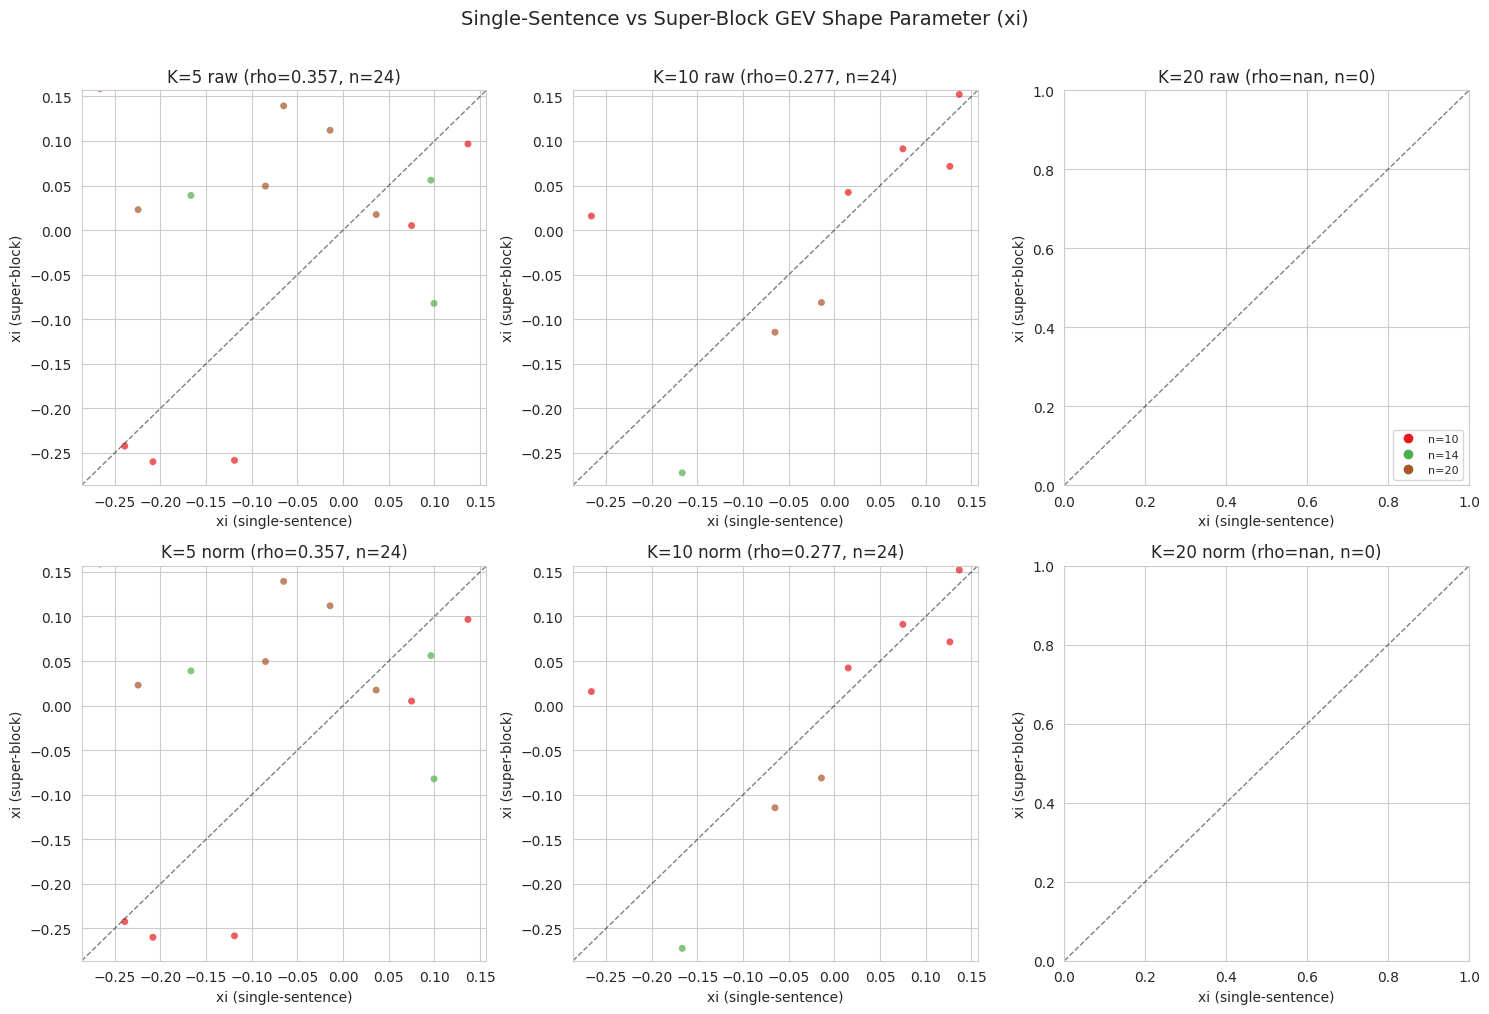

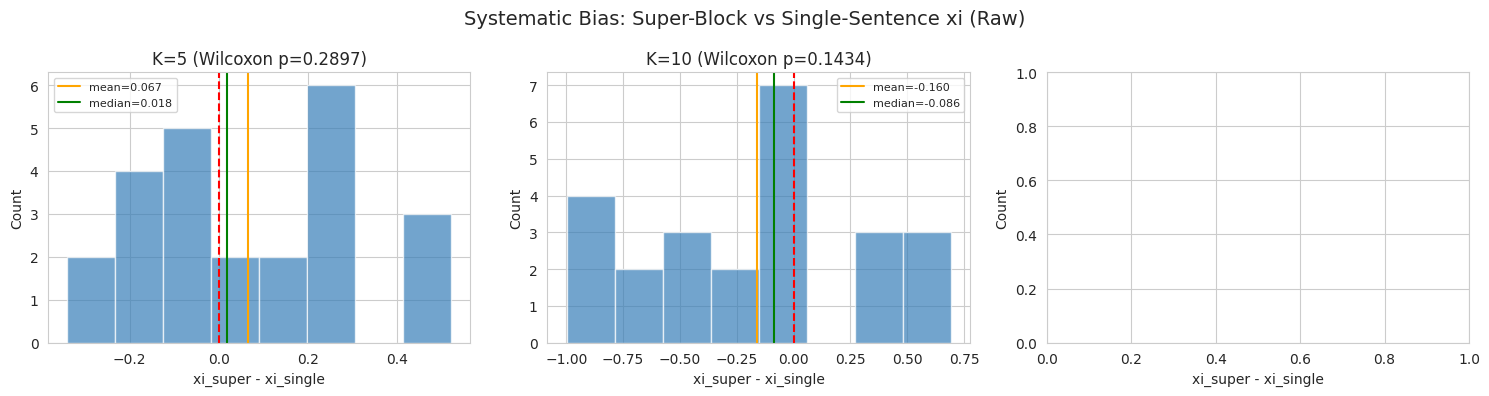

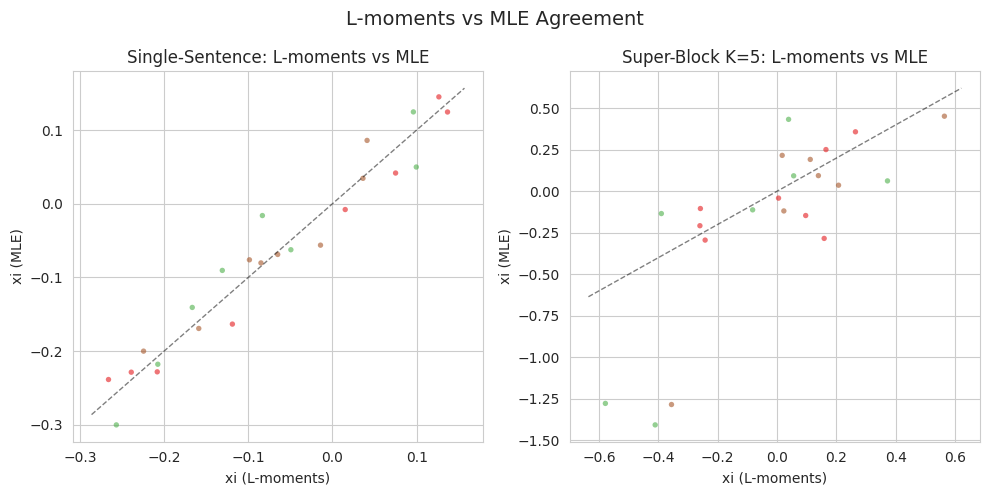


All visualizations complete.


In [12]:
sns.set_style("whitegrid")
bin_colors = {10: "#e41a1c", 12: "#377eb8", 14: "#4daf4a", 16: "#984ea3", 18: "#ff7f00", 20: "#a65628"}

# ---- SUMMARY TABLE ----
print("=" * 80)
print("SUMMARY: Single-Sentence vs Super-Block GEV Shape Parameter Correlations")
print("=" * 80)
print(f"{'K':>4} {'Track':>6} {'Spearman rho':>14} {'p-value':>12} {'95% CI':>20} {'n':>5} {'Pass?':>6}")
print("-" * 80)
for k in K_VALUES:
    for track in ["raw", "norm"]:
        c = comparison.get(k, {}).get(track, {})
        rho = c.get("spearman_rho", float("nan"))
        p = c.get("spearman_p", float("nan"))
        ci_lo = c.get("rho_ci_lo", float("nan"))
        ci_hi = c.get("rho_ci_hi", float("nan"))
        n = c.get("n_pairs", 0)
        passed = "PASS" if (np.isfinite(rho) and rho > 0.8) else "FAIL"
        print(f"{k:>4} {track:>6} {rho:>14.4f} {p:>12.2e} [{ci_lo:>7.3f}, {ci_hi:>7.3f}] {n:>5} {passed:>6}")
print("=" * 80)

# Print sensitivity check results
print("\nSensitivity Checks:")
for name, vals in sorted(checks.items()):
    if "rho" in vals:
        print(f"  {name}: rho={vals['rho']:.4f}" + (f", n={vals.get('n', vals.get('n_pairs', '?'))}" if 'n' in vals or 'n_pairs' in vals else ""))
    elif "pct_valid_raw" in vals:
        print(f"  {name}: {vals['pct_valid_raw']:.1f}% valid raw, {vals['pct_valid_norm']:.1f}% valid norm")
    elif "mean_divergence" in vals:
        print(f"  {name}: mean_div={vals['mean_divergence']:.4f}, {vals.get('pct_within_0.1', 0):.1f}% within 0.1")

# ---- FIG 1: Scatter plots (raw + norm side by side for each K) ----
n_k = len(K_VALUES)
fig, axes = plt.subplots(2, n_k, figsize=(5 * n_k, 10), squeeze=False)
for idx, k in enumerate(K_VALUES):
    for row, track in enumerate(["raw", "norm"]):
        ax = axes[row, idx]
        keys = qualifying[k]
        for key in keys:
            if key not in single_results or key not in super_results[k]:
                continue
            xs = single_results[key][f"xi_{track}_lmom"]
            xb = super_results[k][key][f"xi_{track}"]
            if _xi_is_valid(xs) and _xi_is_valid(xb):
                b = key[1]
                ax.scatter(xs, xb, c=bin_colors.get(b, "gray"), s=25, alpha=0.7, edgecolors="none")
        lims = ax.get_xlim()
        ax.plot(lims, lims, "k--", alpha=0.5, lw=1)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("xi (single-sentence)")
        ax.set_ylabel("xi (super-block)")
        rho_val = comparison.get(k, {}).get(track, {}).get("spearman_rho", float("nan"))
        n_val = comparison.get(k, {}).get(track, {}).get("n_pairs", 0)
        ax.set_title(f"K={k} {track} (rho={rho_val:.3f}, n={n_val})")

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=f"n={b}")
           for b, c in sorted(bin_colors.items()) if b in BINS]
axes[0, -1].legend(handles=handles, loc="lower right", fontsize=8)
fig.suptitle("Single-Sentence vs Super-Block GEV Shape Parameter (xi)", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

# ---- FIG 2: Bias histograms ----
fig, axes = plt.subplots(1, n_k, figsize=(5 * n_k, 4), squeeze=False)
for idx, k in enumerate(K_VALUES):
    ax = axes[0, idx]
    bkey = f"K{k}_raw"
    if bkey in bias_results and bias_results[bkey]["diffs"]:
        diffs = np.array(bias_results[bkey]["diffs"])
        ax.hist(diffs, bins=min(20, max(5, len(diffs)//3)), color="#377eb8", alpha=0.7, edgecolor="white")
        ax.axvline(0, color="red", linestyle="--", lw=1.5)
        ax.axvline(np.mean(diffs), color="orange", linestyle="-", lw=1.5, label=f"mean={np.mean(diffs):.3f}")
        ax.axvline(np.median(diffs), color="green", linestyle="-", lw=1.5, label=f"median={np.median(diffs):.3f}")
        wp = bias_results[bkey].get("wilcoxon_p", float("nan"))
        ax.set_title(f"K={k} (Wilcoxon p={wp:.4f})")
        ax.legend(fontsize=8)
    ax.set_xlabel("xi_super - xi_single")
    ax.set_ylabel("Count")
fig.suptitle("Systematic Bias: Super-Block vs Single-Sentence xi (Raw)", fontsize=14)
fig.tight_layout()
plt.show()

# ---- FIG 3: MLE vs L-moments agreement ----
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax = axes[0]
for key, res in single_results.items():
    if res["raw_lmom_converged"] and res["raw_mle_converged"]:
        xl, xm = res["xi_raw_lmom"], res["xi_raw_mle"]
        if _xi_is_valid(xl) and _xi_is_valid(xm):
            b = key[1]
            ax.scatter(xl, xm, c=bin_colors.get(b, "gray"), s=15, alpha=0.6, edgecolors="none")
lims = ax.get_xlim()
ax.plot(lims, lims, "k--", alpha=0.5, lw=1)
ax.set_xlabel("xi (L-moments)"); ax.set_ylabel("xi (MLE)")
ax.set_title("Single-Sentence: L-moments vs MLE")

ax = axes[1]
k0 = K_VALUES[0]
if k0 in super_results:
    for key, res in super_results[k0].items():
        if _xi_is_valid(res["xi_raw"]) and _xi_is_valid(res["mle_xi_raw"]):
            b = key[1]
            ax.scatter(res["xi_raw"], res["mle_xi_raw"], c=bin_colors.get(b, "gray"), s=15, alpha=0.6, edgecolors="none")
lims = ax.get_xlim()
ax.plot(lims, lims, "k--", alpha=0.5, lw=1)
ax.set_xlabel("xi (L-moments)"); ax.set_ylabel("xi (MLE)")
ax.set_title(f"Super-Block K={k0}: L-moments vs MLE")
fig.suptitle("L-moments vs MLE Agreement", fontsize=14)
fig.tight_layout()
plt.show()

print("\nAll visualizations complete.")